In [2]:
import pandas as pd
import sqlite3 
import matplotlib.pyplot as plt

In [4]:
conn = sqlite3.connect("sales.db")

In [5]:
query ="""SELECT Region , Sum(Sales) as total_sales,
Sum(Profit) as total_profit
FROM sales
GROUP BY Region"""

df_region =pd.read_sql_query(query,conn)
print(df_region)

    Region  total_sales  total_profit
0  Central       501256    39706.3625
1     East       678834    91522.7800
2    South       391750    46749.4303
3     West       725514   108418.4489


In [6]:
df_region['profit_margin']=(
    df_region['total_profit']/
    df_region['total_sales']
) *100
print(df_region)

    Region  total_sales  total_profit  profit_margin
0  Central       501256    39706.3625       7.921374
1     East       678834    91522.7800      13.482351
2    South       391750    46749.4303      11.933486
3     West       725514   108418.4489      14.943674


In [7]:
print(df_region.sort_values(
    by='profit_margin',
    ascending=False 
))

    Region  total_sales  total_profit  profit_margin
3     West       725514   108418.4489      14.943674
1     East       678834    91522.7800      13.482351
2    South       391750    46749.4303      11.933486
0  Central       501256    39706.3625       7.921374


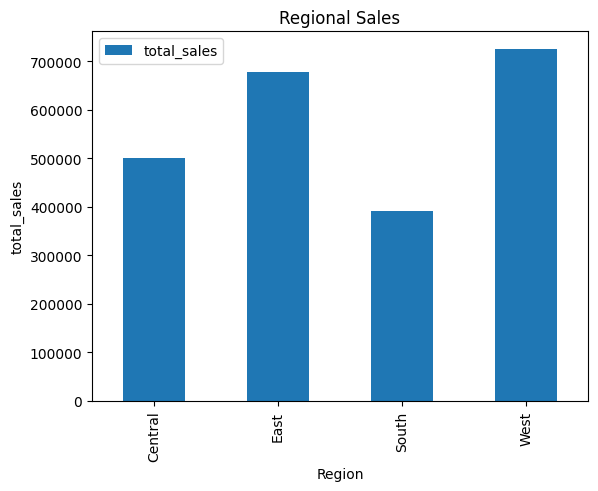

In [9]:
df_region.plot(x='Region',y='total_sales',kind='bar')
plt.title('Regional Sales')
plt.xlabel('Region')
plt.ylabel('total_sales')
plt.show()

In [14]:
query = """
SELECT `SubCategory`,
       SUM(Sales) as total_sales,
       SUM(Profit) as total_profit
FROM sales
GROUP BY `SubCategory`
ORDER BY total_profit DESC
"""

df_sub = pd.read_sql(query, conn)

print(df_sub)

    SubCategory  total_sales  total_profit
0       Copiers       149530    55617.8249
1        Phones       330047    44515.7306
2   Accessories       167401    41936.6357
3         Paper        78475    34053.5693
4       Binders       203428    30221.7633
5        Chairs       328454    26590.1663
6       Storage       223862    21278.8264
7    Appliances       107538    18138.0054
8   Furnishings        91705    13059.1436
9     Envelopes        16477     6964.1767
10          Art        27137     6527.7870
11       Labels        12507     5546.2540
12     Machines       189243     3384.7569
13    Fasteners         3024      949.5182
14     Supplies        46679    -1189.0995
15    Bookcases       114879    -3472.5560
16       Tables       206968   -17725.4811


In [16]:
df_sub.to_csv("top_subcategories_report.csv",index=False)
print('Report Exported Successfully')

Report Exported Successfully
